<a href="https://colab.research.google.com/github/Miclanche/colab-git-assignment2-MA/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Analysis of California Housing Data

## Overview
This project applies clustering and dimensionality reduction techniques to the California Housing dataset to explore structure in the data and relate clusters to housing values.

## Dataset
- Source: `sklearn.datasets.fetch_california_housing`
- Samples: 20,640
- Features: 8 numeric predictors
- Target: Median house value

## Methods
- Preprocessing: standardization of features
- Clustering: K-Means, Agglomerative Clustering
- Dimensionality Reduction: PCA (2 components)
- Evaluation: Silhouette score, visual inspection



Perform necessary preprocessing steps including:
Handling missing values
Feature scaling (if needed)
One-hot encoding for categorical variables (if applicable)
Apply any necessary transformations and normalize or standardize the data as required for your algorithms.


In [34]:
#  Import basics

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [35]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [36]:
# Preprocesing
# Handle missing values
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [37]:
# Define features and target
X = df[housing.feature_names]                   # 8 features
y = df['MedHouseVal']                           # regression target

In [38]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Clustering:
Apply at least two clustering techniques (e.g., K-means clustering, Hierarchical clustering).
Determine the optimal number of clusters for each technique (use methods like the Elbow method, Silhouette score).
Present/Visualize the clusters formed.

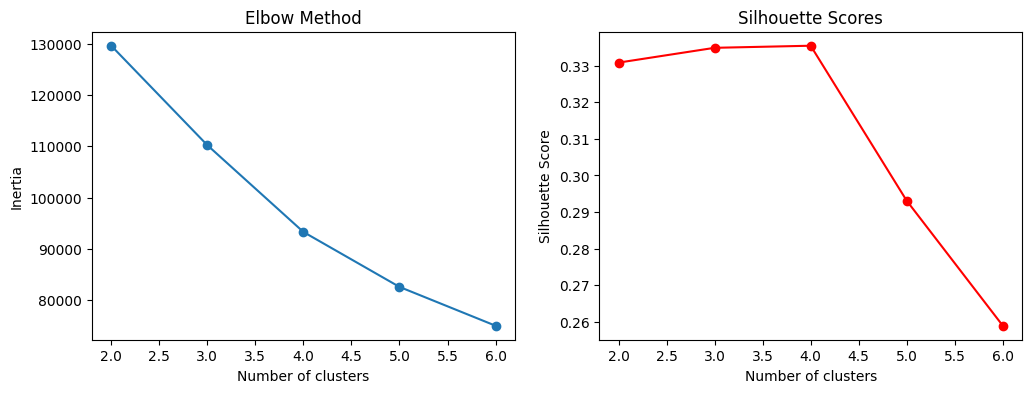

In [39]:
# Determine the optimal number of clusters using Elbow Method and Silhouette Score
inertia_list = []
silhouette_list = []
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_) #km.inertia_ → lower inertia indicates tighter clusters.
    silhouette_list.append(silhouette_score(X_scaled, km.labels_)) #silhouette_score → higher value (closer to 1) indicates better cluster separation.

# Plot Elbow Method and Silhouette Scores
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(2,7), inertia_list, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(range(2,7), silhouette_list, marker='o', color='red')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()


In [40]:
# Apply KMeans clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

#run KMeans 10 times, each time randomly initializing centroids.
#Best result wins : the clustering with the lowest sum of squared distances (inertia).
labels_kmeans = kmeans.fit_predict(X_scaled)


In [41]:
# Apply Agglomerative Clustering with 3 clusters
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_scaled)


In [42]:
# Calculate and print Silhouette Scores for both clustering methods
sil_score_kmeans = silhouette_score(X_scaled, labels_kmeans)
sil_score_agg = silhouette_score(X_scaled, labels_agg)
print("KMeans Silhouette Score:", sil_score_kmeans)
print("Hierarchical Silhouette Score:", sil_score_agg)


KMeans Silhouette Score: 0.3348968181260848
Hierarchical Silhouette Score: 0.32131951032118644


Dimensionality Reduction:
Implement a dimensionality reduction technique (PCA, t-SNE).
Visualize the high-dimensional data in two or three dimensions.

In [43]:
# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['KMeans_Cluster'] = labels_kmeans
df_pca['Hierarchical_Cluster'] = labels_agg


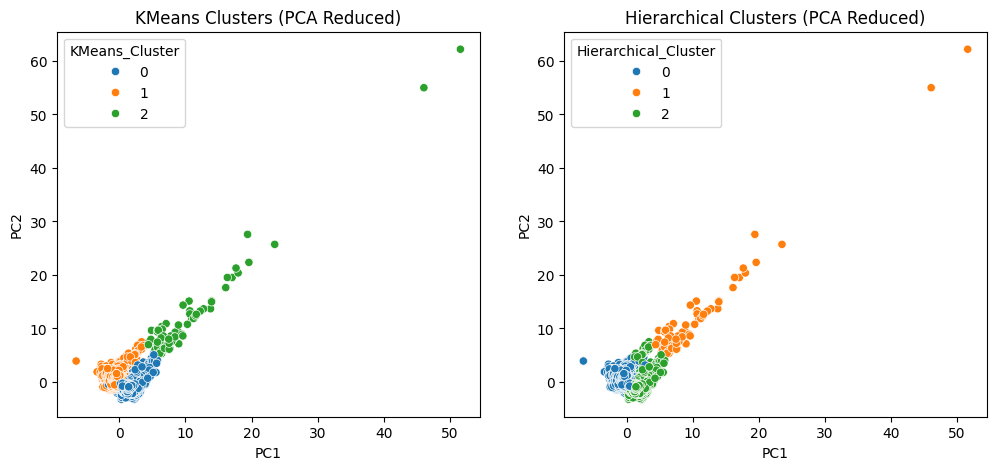

In [44]:
# Visualize the clusters in 2D PCA space
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=df_pca, palette='tab10')
plt.title("KMeans Clusters (PCA Reduced)")
plt.subplot(1,2,2)
sns.scatterplot(x='PC1', y='PC2', hue='Hierarchical_Cluster', data=df_pca, palette='tab10')
plt.title("Hierarchical Clusters (PCA Reduced)")
plt.show()


Model Evaluation:
Evaluate the models using appropriate metrics (e.g., Silhouette score).
Interpret and document the results.


In [45]:
# Calculate and print Silhouette Scores for both clustering methods
sil_score_kmeans = silhouette_score(X_scaled, labels_kmeans)
sil_score_agg = silhouette_score(X_scaled, labels_agg)
print("KMeans Silhouette Score:", sil_score_kmeans)
print("Hierarchical Silhouette Score:", sil_score_agg)


KMeans Silhouette Score: 0.3348968181260848
Hierarchical Silhouette Score: 0.32131951032118644


In [46]:
df_clusters = df.copy()
df_clusters['cluster_kmeans'] = labels_kmeans
df_clusters['cluster_agg'] = labels_agg

# Example: K-Means cluster profiles
cluster_profiles_kmeans = df_clusters.groupby('cluster_kmeans')[housing.feature_names + ['MedHouseVal']].mean()
cluster_profiles_kmeans


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
cluster_kmeans,,,,,,,,,
0,3.805078,29.029667,5.503181,1.081928,1287.181017,3.037686,37.950337,-121.729971,1.973203
1,3.921265,28.420695,5.206308,1.071632,1532.655718,3.098150,33.942695,-118.009083,2.140319
2,3.372851,18.697368,31.977939,6.703742,296.171053,2.496145,37.659079,-119.373289,1.625816


Deployment and Monitoring:
Discuss a hypothetical scenario where your best-performing model is deployed to production.
Include potential challenges in deployment, such as latency, scalability, and maintenance.
Propose strategies for model monitoring and updating as new data becomes available.